----------------Row data-----------
    order_id customer_name            product     category    price  quantity  \
0       1001       Dheeraj             Laptop  Electronics  55000.0       1.0   
1       1002         Kunal         Smartphone  electronics  20000.0       2.0   
2       1003          None         Headphones  Accessories   2500.0       3.0   
3       1004       Praveen           Keyboard  Accessories      NaN       2.0   
4       1005          Ravi              Mouse  Accessories    800.0       NaN   
5       1006          Amit             Tablet  Electronics -18000.0       1.0   
6       1007          Neha         Smartwatch    Wearables   5000.0       2.0   
7       1008         Pooja  Bluetooth Speaker  Accessories   3000.0       2.0   
8       1009         Rohit            Monitor  Electronics  12000.0       1.0   
9       1010        Anjali            Printer  Electronics   9000.0       1.0   
10      1010        Anjali            Printer  Electronics   9000.0      

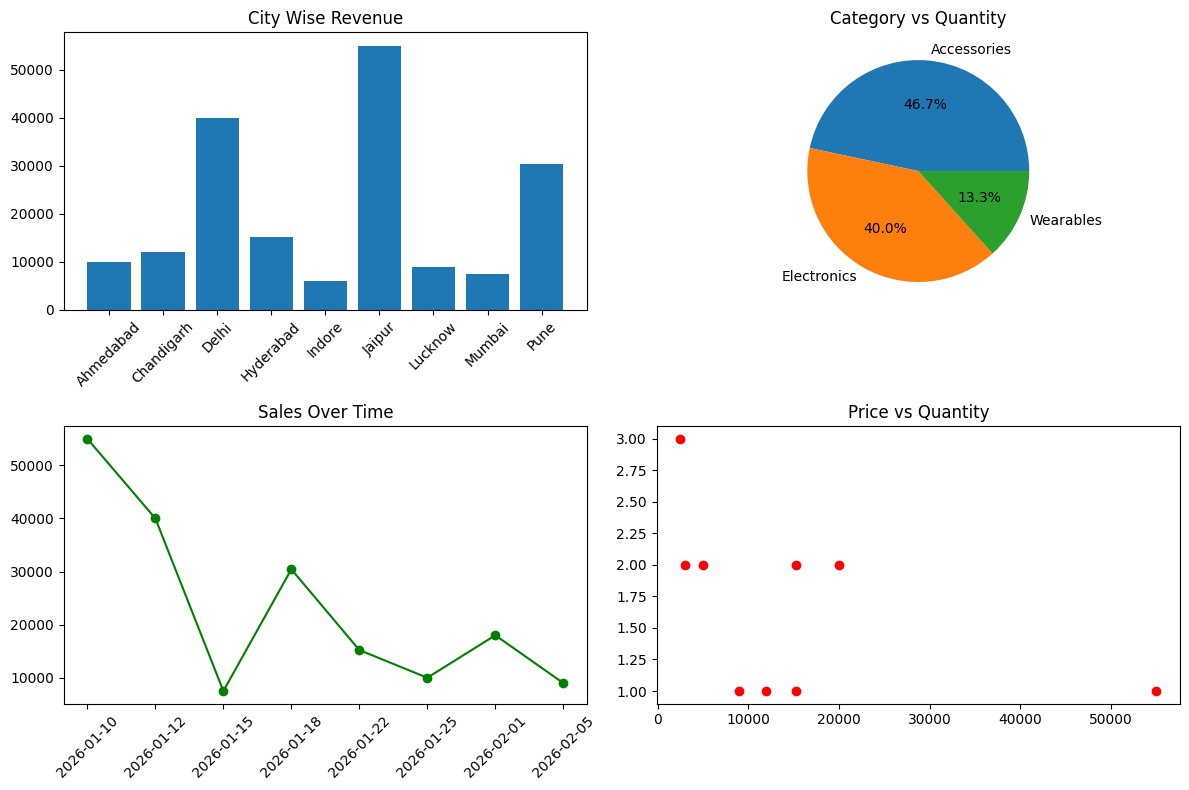

In [15]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

url="https://raw.githubusercontent.com/student-dheerajyadav/DataScience__45days/main/ecommerce.json"
df=pd.read_json(url)
print("----------------Row data-----------")
print(df)
# print("-------------remove NaN value of Quantity--------- ")
df.dropna(subset=["quantity"],inplace=True)
df.drop_duplicates(subset=["customer_name"],inplace=True)
# df.dropna(subset=["customer_name"],inplace=True)
df["customer_name"].fillna("unkonwn",inplace=True)
# print(df)
# print(" --------------remove negative value and plce NaN of price-------------  ")
df.loc[df["price"]<0,"price"]=np.nan
# print(df)
# print("-----------place Nan-> mean of price---------------")
df["price"].fillna(df["price"].mean(),inplace=True)
# print(df)
# print("---------print missing date--------")
df["order_date"]=df["order_date"].replace("",np.nan)
df["order_date"].fillna(method="bfill",inplace=True)
print("Final clean data")
df["category"] = df["category"].str.capitalize()
df["city"] = df["city"].str.strip()
df["Total_Sales"]=df["price"]*df["quantity"]
# print(df)
fig, aux = plt.subplots(2,2, figsize=(12,8))

# 1. City vs Total Sales (Bar chart)
city_sales = df.groupby("city")["Total_Sales"].sum()

aux[0][0].bar(city_sales.index, city_sales.values)
aux[0][0].set_title("City Wise Revenue")
aux[0][0].tick_params(axis='x', rotation=45)

# 2. Category vs Quantity (Pie chart)
category_quantity = df.groupby("category")["quantity"].sum()
aux[0][1].pie(category_quantity.values, labels=category_quantity.index, autopct="%1.1f%%")
aux[0][1].set_title("Category vs Quantity")

# 3. Sales over Time (Line chart)
date_sales = df.groupby("order_date")["Total_Sales"].sum()
aux[1][0].plot(date_sales.index, date_sales.values, marker="o", color="green")
aux[1][0].set_title("Sales Over Time")
aux[1][0].tick_params(axis='x', rotation=45)

# 4. Price vs Quantity (Scatter plot)
aux[1][1].scatter(df["price"], df["quantity"], color="red")
aux[1][1].set_title("Price vs Quantity")
plt.gcf().canvas.get_supported_filetypes()
plt.savefig("min-project1.jpg")
plt.tight_layout()
print(df)
plt.show()


